In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata, scvelo as scv
import scanpy as sc

# ─── 1.  SIMULATION ────────────────────────────────────────────────────────
def sample_unit_ball(n, dim, rng):
    x = rng.normal(size=(n, dim))                     # sample from normal
    x /= np.linalg.norm(x, axis=1, keepdims=True)     # normalize to unit sphere
    r = rng.random(n) ** (1.0 / dim)                   # scale radii to uniform inside ball
    return x * r[:, None]


def noisy_null_field(n=500, dims=(2, 8, 32, 128),
                     noise_std=1e-2, seed=42):
    rng = np.random.default_rng(seed)
    out = {}
    for d in dims:
        tag = f"d{d}"
        X = sample_unit_ball(n, d, rng)
        V = rng.normal(0.0, noise_std, size=X.shape)
        out[tag] = dict(X=X, V=V)
    return out

simulation_results = noisy_null_field()


# Create folder if needed
out_dir = "./data/neg_control/"
os.makedirs(out_dir, exist_ok=True)

# Save each dataset
for tag, result in simulation_results.items():
    X, V = result["X"], result["V"]

    df_X = pd.DataFrame(X)
    df_V = pd.DataFrame(V)

    df_X.to_csv(os.path.join(out_dir, f"X_{tag}.csv"), index=False)
    df_V.to_csv(os.path.join(out_dir, f"V_{tag}.csv"), index=False)

print("Saved all simulated X and V to ./data/neg_control/")

Saved all simulated X and V to ./data/neg_control/


computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/18 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/18 cores)
    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.

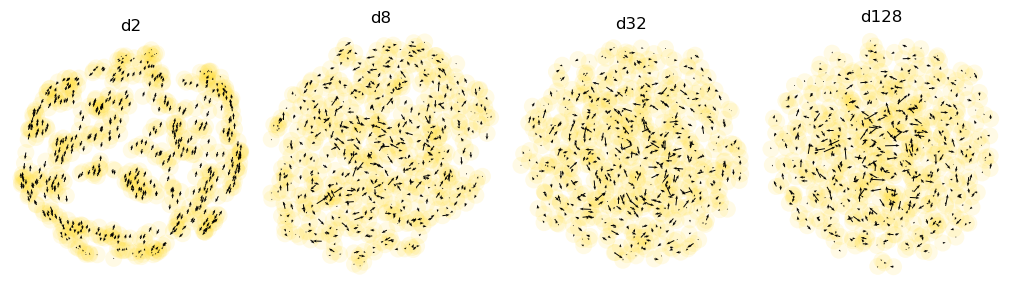

In [5]:
# ─── 2.  PLOTTING ──────────────────────────────────────────────────────────
np.random.seed(42)

fig, axs = plt.subplots(1, 4, figsize=(10, 4), constrained_layout=True)

for ax, (name, result) in zip(axs, simulation_results.items()):
    X, V = result["X"], result["V"]

    adata = anndata.AnnData(X)
    adata.layers["position"] = X
    adata.layers["velocity"] = V

    scv.pp.neighbors(adata, n_neighbors=30, use_rep="X")
    sc.tl.umap(adata, min_dist=0.3)
    scv.tl.velocity_graph(adata, xkey="position", vkey="velocity")
    scv.tl.velocity_embedding(adata, basis="umap")          # still unit-normalized

    X_umap = adata.obsm["X_umap"]
    V_umap = adata.obsm["velocity_umap"]

    ax.set_title(name)
    ax.set_aspect("equal")
    ax.axis("off")

    # yellow points
    ax.scatter(X_umap[:, 0], X_umap[:, 1],
               c="#FFD700", s=150, alpha=0.10, edgecolors="none")

    # quiver with longer shafts & slimmer heads
    ax.quiver(
        X_umap[:, 0], X_umap[:, 1],
        V_umap[:, 0], V_umap[:, 1],
        color="black",
        angles="xy",
        scale_units="xy",
        scale=0.5,        # smaller → longer arrows
        width=0.004,       # line thickness
        headwidth=3,       # shrink head
        headlength=4,
        headaxislength=3
    )

plt.show()


[PCA] Skipped (input dim = 2)
[Init] Target embedding dimension: 2D
[Init] Computing phase distance graph …
[Init] Embedding with UMAP (precomputed) …
[TPS] Fitting geometry spline …
[TPS] Mapping vector field …
[TPS] Fitting vector-field spline …
[Init] Done.


NameError: name 'd' is not defined

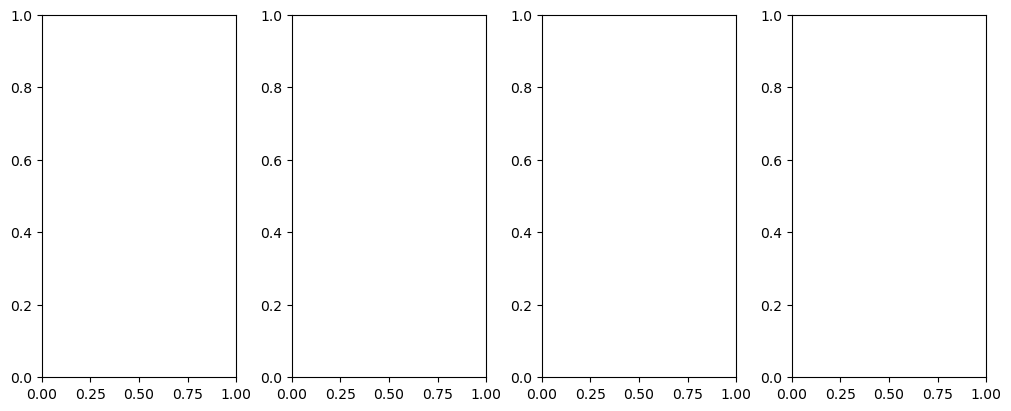

In [6]:
from scripts.VectorFieldEmbedder import *

# Prepare plot: 1 × 4 grid for dims = 2, 4, 8, 16
dims = [2, 4, 8, 16]
fig, axs = plt.subplots(1, 4, figsize=(10, 4), constrained_layout=True)

for ax, (name, result) in zip(axs, simulation_results.items()):
    X, V = result["X"], result["V"]

    # Your method
    emb = VectorFieldEmbedder(
        X, V,
        use_PCA=False,
        embed_kwargs={"n_neighbors": 30, "min_dist": 0.3}
    )
    emb.initialize_embedding()

    # Extract embedded positions and projected velocity field
    X_emb = emb.X_emb
    V_emb = emb.V_emb

    # Plot like before
    ax.set_title(name)
    ax.set_aspect("equal")
    ax.axis("off")

    ax.scatter(X_emb[:, 0], X_emb[:, 1],
               c="#FFD700", s=150, alpha=0.10, edgecolors="none")

    ax.quiver(
        X_emb[:, 0], X_emb[:, 1],
        V_emb[:, 0], V_emb[:, 1],
        color="black",
        angles="xy",
        scale_units="xy",
        scale=0.5,         # longer shafts
        width=0.004,
        headwidth=3,
        headlength=4,
        headaxislength=3
    )

plt.show()